In [ ]:
import pandas as pd


In [ ]:
"archive(8).zip"

'archive(8).zip'

In [ ]:
!unzip "archive (8).zip"

Archive:  archive (8).zip
replace appointments.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
df = pd.read_csv('appointments.csv')
df.head()

,appointment_id,patient_id,doctor_id,appointment_date,appointment_time,reason_for_visit,status
0,A001,P034,D009,2023-08-09,15:15:00,Therapy,Scheduled
1,A002,P032,D004,2023-06-09,14:30:00,Therapy,No-show
2,A003,P048,D004,2023-06-28,8:00:00,Consultation,Cancelled
3,A004,P025,D006,2023-09-01,9:15:00,Consultation,Cancelled
4,A005,P040,D003,2023-07-06,12:45:00,Emergency,No-show


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   appointment_id    200 non-null    object
 1   patient_id        200 non-null    object
 2   doctor_id         200 non-null    object
 3   appointment_date  200 non-null    object
 4   appointment_time  200 non-null    object
 5   reason_for_visit  200 non-null    object
 6   status            200 non-null    object
dtypes: object(7)
memory usage: 11.1+ KB


In [ ]:
print("Missing Values:\n",df.isnull().sum())
print("\nDuplicate Rows:",df.duplicated().sum())



Missing Values:
 appointment_id      0
patient_id          0
doctor_id           0
appointment_date    0
appointment_time    0
reason_for_visit    0
status              0
dtype: int64

Duplicate Rows: 0


/tmp/ipykernel_3578/1302889376.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='reason_for_visit', order=df['reason_for_visit'].value_counts().index, palette='viridis')


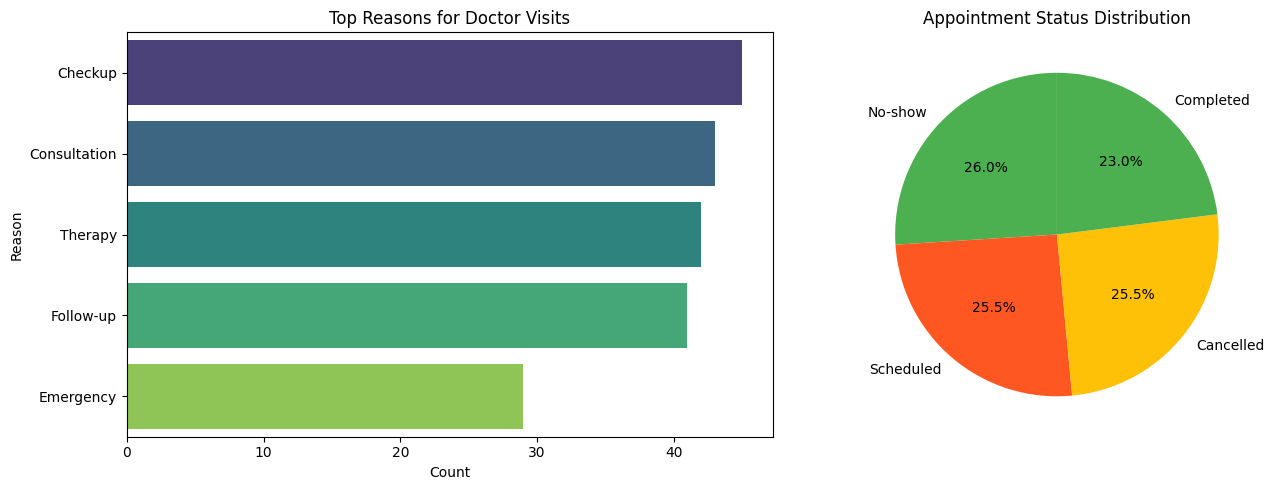

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

# Figure size set karna
plt.figure(figsize=(14, 5))

# Chart 1: Top Reasons for Visit
plt.subplot(1, 2, 1)
sns.countplot(data=df, y='reason_for_visit', order=df['reason_for_visit'].value_counts().index, palette='viridis')
plt.title('Top Reasons for Doctor Visits')
plt.xlabel('Count')
plt.ylabel('Reason')

# Chart 2: Appointment Status
plt.subplot(1, 2, 2)
df['status'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#4CAF50', '#FF5722', '#FFC107'], startangle=90)
plt.title('Appointment Status Distribution')
plt.ylabel('')

plt.tight_layout()
plt.show()


In [ ]:
# 1. Reasons for Visit ka table dekhne ke liye
print("=== Table 1: Reasons for Doctor Visits ===")
reasons_table = df['reason_for_visit'].value_counts().reset_index()
reasons_table.columns = ['Reason for Visit', 'Total Patients']
display(reasons_table)

print("\n" + "="*40 + "\n")

# 2. Appointment Status ka table dekhne ke liye
print("=== Table 2: Appointment Status Distribution ===")
status_table = df['status'].value_counts().reset_index()
status_table.columns = ['Appointment Status', 'Count']
# Percentage nikalne ke liye
status_table['Percentage (%)'] = (status_table['Count'] / status_table['Count'].sum() * 100).round(1)
display(status_table)



=== Table 1: Reasons for Doctor Visits ===


,Reason for Visit,Total Patients
0,Checkup,45
1,Consultation,43
2,Therapy,42
3,Follow-up,41
4,Emergency,29




=== Table 2: Appointment Status Distribution ===


,Appointment Status,Count,Percentage (%)
0,No-show,52,26.0
1,Scheduled,51,25.5
2,Cancelled,51,25.5
3,Completed,46,23.0


/tmp/ipykernel_3578/1756592657.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3578/1756592657.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


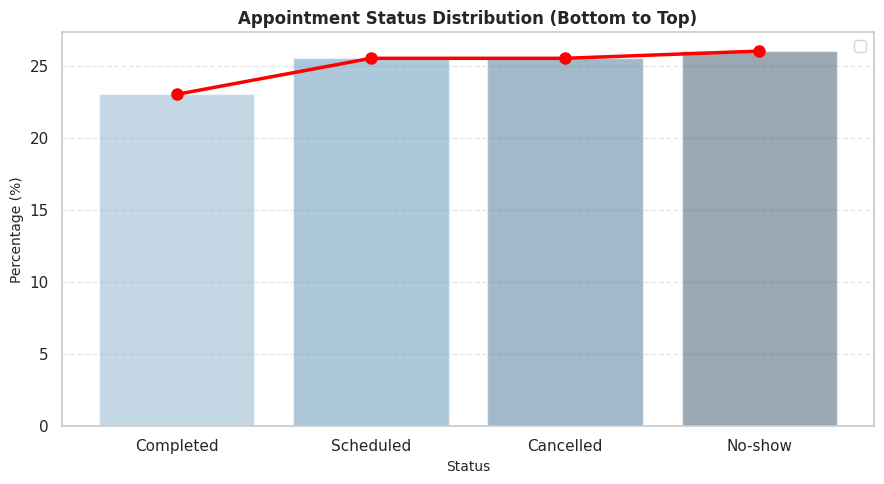

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Data load aur sort karna (Bottom to Top trend ke liye)
df_appointments = pd.read_csv("appointments.csv")
status_counts = (
    df_appointments["status"].value_counts(normalize=True).reset_index()
)
status_counts.columns = ["Status", "Percentage"]
status_counts["Percentage"] = status_counts["Percentage"] * 100

# Chote se bade value ki taraf sort karna
status_counts = status_counts.sort_values(by="Percentage", ascending=True)

# Plotting
plt.figure(figsize=(9, 5))
sns.barplot(
    x="Status",
    y="Percentage",
    data=status_counts,
    alpha=0.5,
    palette="Blues_d",
)
plt.plot(
    status_counts["Status"],
    status_counts["Percentage"],
    color="red",
    marker="o",
    linewidth=2.5,
    markersize=8,

)

plt.title(
    "Appointment Status Distribution (Bottom to Top)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Status", fontsize=10)
plt.ylabel("Percentage (%)", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

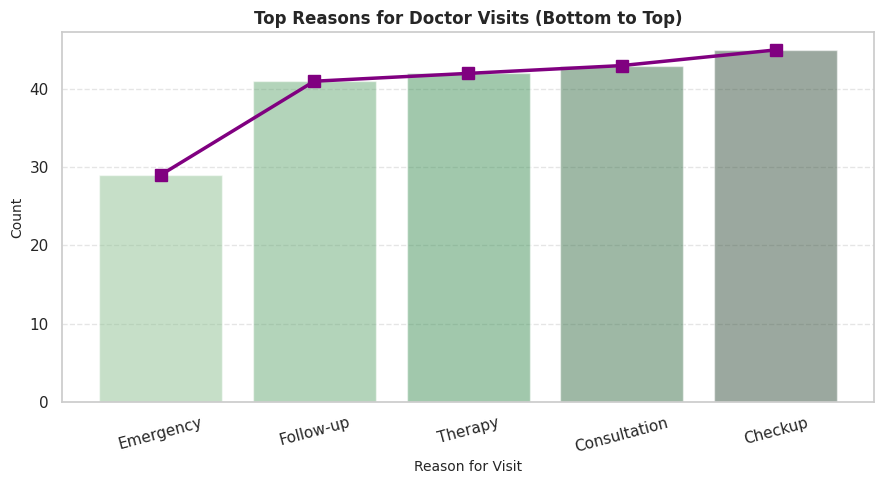

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df_appointments = pd.read_csv("appointments.csv")
visit_counts = (
    df_appointments["reason_for_visit"].value_counts().reset_index()
)
visit_counts.columns = ["Reason", "Count"]

# Sort ascending for Bottom to Top flow
visit_counts = visit_counts.sort_values(by="Count", ascending=True)

plt.figure(figsize=(9, 5))
sns.barplot(
    x="Reason", y="Count", data=visit_counts, alpha=0.5, palette="Greens_d", hue='Reason', legend=False
)
plt.plot(
    visit_counts["Reason"],
    visit_counts["Count"],
    color="purple",
    marker="s",
    linewidth=2.5,
    markersize=8,

)

plt.title(
    "Top Reasons for Doctor Visits (Bottom to Top)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Reason for Visit", fontsize=10)
plt.ylabel("Count", fontsize=10)
plt.xticks(rotation=15)
plt.grid(axis="y", linestyle="--", alpha=0.5)
# Removed plt.legend() as it was empty and causing a warning
plt.tight_layout()
plt.show()

/tmp/ipykernel_3578/3272707421.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_3578/3272707421.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


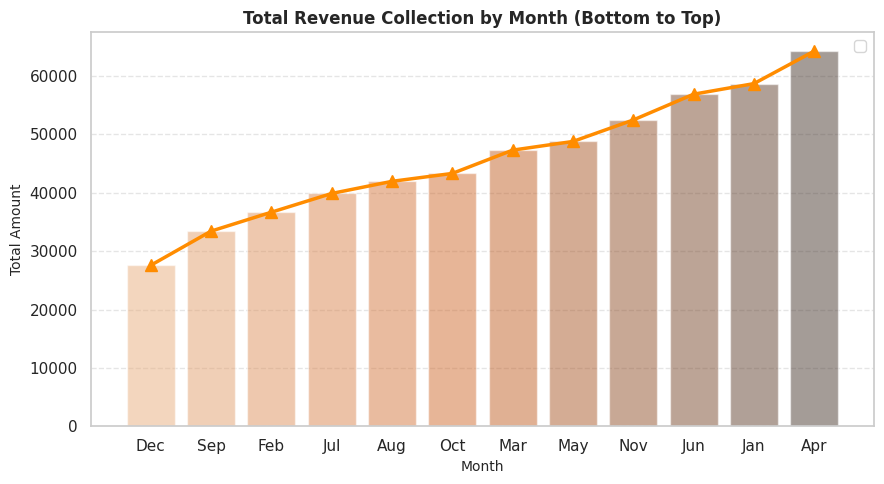

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df_billing = pd.read_csv("billing.csv")

# Date and Month column handling
if "bill_date" in df_billing.columns:
    df_billing["bill_date"] = pd.to_datetime(df_billing["bill_date"])
    df_billing["Month"] = df_billing["bill_date"].dt.strftime("%b")
elif "date" in df_billing.columns:
    df_billing["date"] = pd.to_datetime(df_billing["date"])
    df_billing["Month"] = df_billing["date"].dt.strftime("%b")

# Find amount column dynamically
amt_col = [c for c in df_billing.columns if "amount" in c.lower()][0] # Corrected to specifically find 'amount'

monthly_billing = (
    df_billing.groupby("Month")[amt_col].sum().reset_index()
)
# Sort to create bottom to top incline
monthly_billing = monthly_billing.sort_values(by=amt_col, ascending=True)

plt.figure(figsize=(9, 5))
sns.barplot(
    x="Month",
    y=amt_col,
    data=monthly_billing,
    alpha=0.5,
    palette="Oranges_d",
)
plt.plot(
    monthly_billing["Month"],
    monthly_billing[amt_col],
    color="darkorange",
    marker="^",
    linewidth=2.5,
    markersize=8,

)

plt.title(
    "Total Revenue Collection by Month (Bottom to Top)",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Month", fontsize=10)
plt.ylabel("Total Amount", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

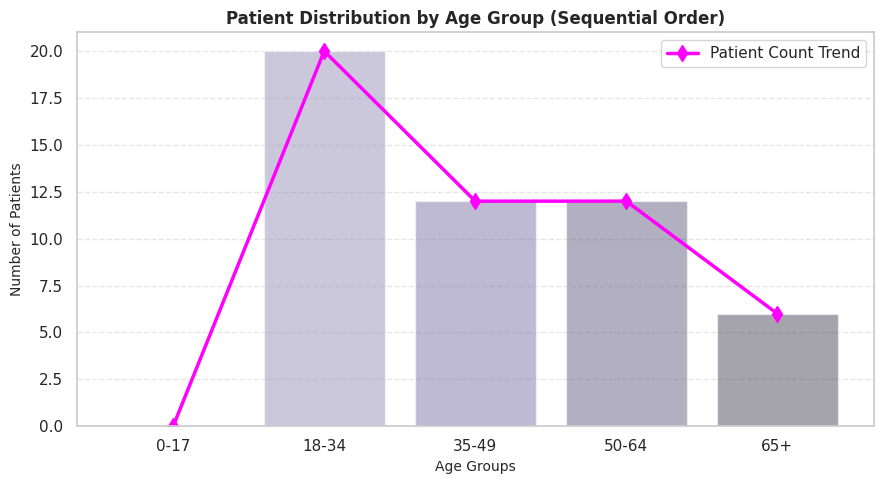

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from datetime import datetime

df_patients = pd.read_csv("patients.csv")

# Convert 'date_of_birth' to datetime objects
df_patients['date_of_birth'] = pd.to_datetime(df_patients['date_of_birth'])

# Calculate age based on a reference date (e.g., beginning of 2023)
reference_date = datetime(2023, 1, 1)
df_patients['Age'] = (reference_date - df_patients['date_of_birth']).dt.days // 365

age_col = 'Age' # Now 'Age' column exists

# Making age brackets
bins = [0, 17, 34, 49, 64, df_patients[age_col].max() + 1] # Define numerical boundaries for age groups
labels = ["0-17", "18-34", "35-49", "50-64", "65+"]
df_patients["Age_Group"] = pd.cut(
    df_patients[age_col], bins=bins, labels=labels, right=False
)

age_counts = (
    df_patients["Age_Group"].value_counts().reset_index()
)
age_counts.columns = ["Age Group", "Patient Count"]

# Convert 'Age Group' to a categorical type with the desired order
age_counts['Age Group'] = pd.Categorical(age_counts['Age Group'], categories=labels, ordered=True)

# Sort by the ordered categorical 'Age Group' to get the desired sequence
age_counts = age_counts.sort_values(by="Age Group", ascending=True)

plt.figure(figsize=(9, 5))
sns.barplot(
    x="Age Group",
    y="Patient Count",
    data=age_counts,
    alpha=0.5,
    palette="Purples_d",
    hue="Age Group", legend=False
)
plt.plot(
    age_counts["Age Group"],
    age_counts["Patient Count"],
    color="magenta",
    marker="d",
    linewidth=2.5,
    markersize=8,
    label="Patient Count Trend", # Changed label for clarity
)

plt.title(
    "Patient Distribution by Age Group (Sequential Order)", # Updated title
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Age Groups", fontsize=10)
plt.ylabel("Number of Patients", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

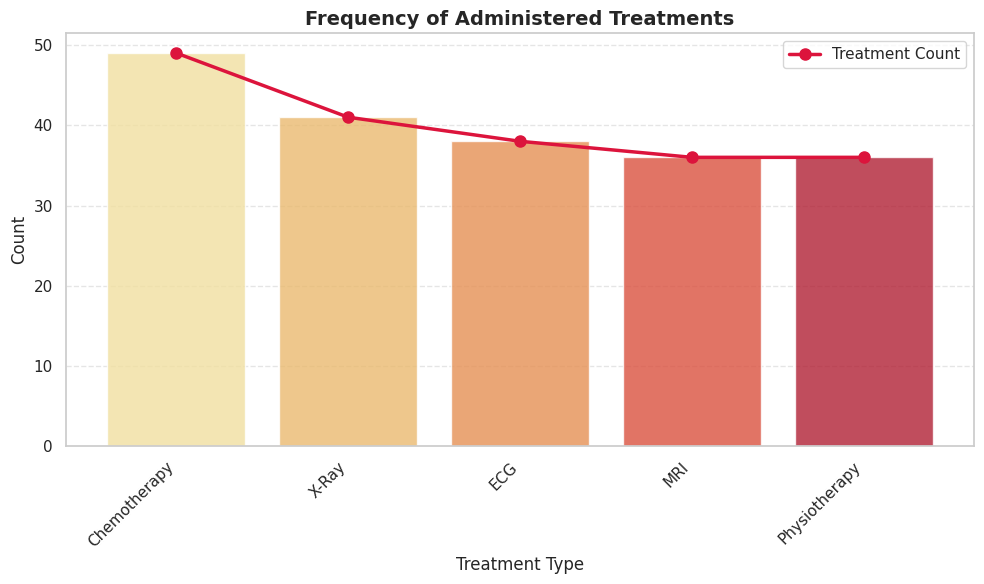

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df_treatments = pd.read_csv("treatments.csv")

# Dynamic column selection for treatment name/type - explicitly use 'treatment_type'
treat_col = 'treatment_type'

treat_counts = df_treatments[treat_col].value_counts().reset_index()
treat_counts.columns = ["Treatment", "Count"]

# Sort in descending order to show most frequent treatments first
treat_counts = treat_counts.sort_values(by="Count", ascending=False)

# Consider showing top N treatments if there are too many unique types, for better readability
# For now, let's plot all of them to see the full distribution, or you can use .head(N) if needed.

plt.figure(figsize=(10, 6)) # Adjusted figure size for potentially more bars
sns.barplot(
    x="Treatment", y="Count", data=treat_counts, alpha=0.8, palette="YlOrRd", hue="Treatment", legend=False
)
plt.plot(
    treat_counts["Treatment"],
    treat_counts["Count"],
    color="crimson",
    marker="o", # Changed marker to circle for better visibility
    linewidth=2.5,
    markersize=8,
    label="Treatment Count", # Updated label
)

plt.title(
    "Frequency of Administered Treatments", # Updated title
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Treatment Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
df_doctors = pd.read_csv('doctors.csv')
print("Doctors Data:")
display(df_doctors.head())

Doctors Data:


,doctor_id,first_name,last_name,specialization,phone_number,years_experience,hospital_branch,email
0,D001,David,Taylor,Dermatology,8322010158,17,Westside Clinic,dr.david.taylor@hospital.com
1,D002,Jane,Davis,Pediatrics,9004382050,24,Eastside Clinic,dr.jane.davis@hospital.com
2,D003,Jane,Smith,Pediatrics,8737740598,19,Eastside Clinic,dr.jane.smith@hospital.com
3,D004,David,Jones,Pediatrics,6594221991,28,Central Hospital,dr.david.jones@hospital.com
4,D005,Sarah,Taylor,Dermatology,9118538547,26,Central Hospital,dr.sarah.taylor@hospital.com
